Note: Using monthly maps to create Kd490 mean from 2013-2023

In [1]:
import h5pyd
import h5py
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import haversine
from haversine import haversine, Unit
from datetime import datetime
from netCDF4 import Dataset
import h5netcdf
import os

In [2]:
#Ok let's read the data in first and add in a date
path = "C:/Users/sarah/Desktop/ORKA/Data/NASAOceanColor/AQUA_MODIS_KD_Monthly_Mapped"
files = os.listdir(path)[36:168] #restricting it to files 36-168 focuses the time on 2013-2023
for i in files:
    if i == files[0]:
        file = os.path.join(path, i)
        print(file)
        d = xr.open_dataset(file, engine="netcdf4")
        df = d.Kd_490.to_dataframe().reset_index()
        df["date"] = datetime.strptime(i[11:19], "%Y%m%d").date()
    else:
        file = os.path.join(path, i)
        print(file)
        d = xr.open_dataset(file, engine="netcdf4")
        test = d.Kd_490.to_dataframe().reset_index()
        test["date"] = datetime.strptime(i[11:19], "%Y%m%d").date()
        df = pd.concat([df,test])
        print(i)
df = df.reset_index()

C:/Users/sarah/Desktop/ORKA/Data/NASAOceanColor/AQUA_MODIS_KD_Monthly_Mapped\AQUA_MODIS.20130101_20130131.L3m.MO.KD.x_Kd_490.nc
C:/Users/sarah/Desktop/ORKA/Data/NASAOceanColor/AQUA_MODIS_KD_Monthly_Mapped\AQUA_MODIS.20130201_20130228.L3m.MO.KD.x_Kd_490.nc
AQUA_MODIS.20130201_20130228.L3m.MO.KD.x_Kd_490.nc
C:/Users/sarah/Desktop/ORKA/Data/NASAOceanColor/AQUA_MODIS_KD_Monthly_Mapped\AQUA_MODIS.20130301_20130331.L3m.MO.KD.x_Kd_490.nc
AQUA_MODIS.20130301_20130331.L3m.MO.KD.x_Kd_490.nc
C:/Users/sarah/Desktop/ORKA/Data/NASAOceanColor/AQUA_MODIS_KD_Monthly_Mapped\AQUA_MODIS.20130401_20130430.L3m.MO.KD.x_Kd_490.nc
AQUA_MODIS.20130401_20130430.L3m.MO.KD.x_Kd_490.nc
C:/Users/sarah/Desktop/ORKA/Data/NASAOceanColor/AQUA_MODIS_KD_Monthly_Mapped\AQUA_MODIS.20130501_20130531.L3m.MO.KD.x_Kd_490.nc
AQUA_MODIS.20130501_20130531.L3m.MO.KD.x_Kd_490.nc
C:/Users/sarah/Desktop/ORKA/Data/NASAOceanColor/AQUA_MODIS_KD_Monthly_Mapped\AQUA_MODIS.20130601_20130630.L3m.MO.KD.x_Kd_490.nc
AQUA_MODIS.20130601_20130630

In [3]:
df
print("Number of time steps is", df.date.nunique())
print("Lat/lon combos is", len(df[['lon','lat']].drop_duplicates()))

Number of time steps is 132
Lat/lon combos is 7776


In [4]:
sites = pd.read_csv('C:/Users/sarah/Documents/GitHub/ORKA_StatusReport_FollowupPaper/StatusReport_FollowupPaper_Data/MasterSiteList_FollowupPaper.csv')
sites = sites.iloc[0:15,0:8]

In [22]:
%%time
#Ok here I'm finding which ROMS grid cell is closest to each site 
#then pulling out the ROMS data for each nearest grid cell and putting it into a dataframe called 'df_forsites' 
lat = sites.SiteLatitude[0]
lon = sites.SiteLongitude[0]
site = (lat, lon)
site_rounded = (round(lat,2), round(lon, 2))
df_sub = df.loc[(df.lat < site[0] +0.02) & (df.lat > site[0]-0.02)]
def hav_dist(row):
    site2 = (row["lat"],row["lon"])
    return haversine(site,site2)
dist = df.apply(hav_dist, axis = 1)
index1 = dist[dist == dist.min()].index
df_forsites = df.iloc[index1.values[:],]

for i in range(1,len(sites)): 
    #print(i, "has the latitude", sites.SiteLatitude[i])
    site = (sites.SiteLatitude[i], sites.SiteLongitude[i])
    df_sub = df.loc[(df.lat < site[0] +0.02) & (df.lat > site[0]-0.02)]
    dist = df_sub.apply(hav_dist, axis = 1)
    index1 = dist[dist == dist.min()].index
    closest = df.iloc[index1.values[:],]
    print(closest.iloc[1,1:3])
    df_forsites = pd.concat([df_forsites,closest])
    print(i," is finished, hooray!")
df_forsites['date'] = pd.to_datetime(df_forsites.date)

lat     45.229168
lon   -123.979164
Name: 9984, dtype: object
1  is finished, hooray!
lat    44.770832
lon    -124.0625
Name: 10774, dtype: object
2  is finished, hooray!
lat    44.729168
lon    -124.0625
Name: 10846, dtype: object
3  is finished, hooray!
lat     43.354168
lon   -124.395836
Name: 13214, dtype: object
4  is finished, hooray!
lat       43.3125
lon   -124.395836
Name: 13286, dtype: object
5  is finished, hooray!
lat       43.3125
lon   -124.395836
Name: 13286, dtype: object
6  is finished, hooray!
lat     42.8125
lon   -124.5625
Name: 14146, dtype: object
7  is finished, hooray!
lat     42.770832
lon   -124.604164
Name: 14217, dtype: object
8  is finished, hooray!
lat     42.729168
lon   -124.520836
Name: 14291, dtype: object
9  is finished, hooray!
lat       42.6875
lon   -124.479164
Name: 14364, dtype: object
10  is finished, hooray!
lat     42.6875
lon   -124.4375
Name: 14365, dtype: object
11  is finished, hooray!
lat       42.4375
lon   -124.479164
Name: 14796, dtype

IndexError: single positional indexer is out-of-bounds

In [12]:
#Check which grid cells from ROMs model are pulled out to correspond with which sites
#Note: we are only getting 13 unique sites here. Looks like harris beach and chetco get collapsed into a single site (index 13 and
#14 in sites) and then simpson and drake (index 5 and 6 in sites) are getting collapse down into one.
df_forsites[["lat","lon"]].drop_duplicates()

,lat,lon
1992,45.354168,-123.979164
2208,45.229168,-123.979164
2998,44.770832,-124.062500
3070,44.729168,-124.062500
5438,43.354168,-124.395836
5510,43.312500,-124.395836
6370,42.812500,-124.562500
6441,42.770832,-124.604164
6515,42.729168,-124.520836
6588,42.687500,-124.479164


In [13]:
#90th percentile of kd values at each site
df90 = df_forsites.groupby(["lat","lon"]).Kd_490.quantile(q = 0.9).reset_index()
df90

#and then assign to the matrix (while duplicating values for drake point and chetco). Since it's in backwards order, I will be doubling
#indices 0 and 7. 
df90 = pd.concat([pd.DataFrame(df90.iloc[0,:]).T,df90.iloc[0:8,:], df90.iloc[7:13,:] ]).reset_index()
df90
thing = df90.iloc[:,3]
thing = thing.iloc[::-1]
sites["P90_Kd490"] = thing.values
sites

,Site,SiteCode,Area,AreaCode,Port,SiteLatitude,SiteLongitude,Number2023Trans_Estiamted,P90_Kd490
0,Cape Lookout,LOOK,Cape Lookout,LKOUT,Pacific City,45.336730,-123.980000,0,2.37354
1,Pacific City,PACC,Cape Lookout,LKOUT,Pacific City,45.212470,-123.985186,12,2.21060
2,Cape Foulweather,FOUL,Cape Foulweather,FOULW,Depoe Bay,44.784468,-124.074200,44,1.78800
3,Otter Rock,OTRK,Cape Foulweather,FOULW,Depoe Bay,44.746630,-124.072591,52,2.23120
4,Gregory Point,GREG,Cape Arago,ARAGO,Coos Bay,43.339313,-124.378642,10,1.61710
5,Simpson Reef,SIMP,Cape Arago,ARAGO,Coos Bay,43.315740,-124.404422,16,1.63300
6,Drake Point,DRAK,Cape Arago,ARAGO,Coos Bay,43.300839,-124.400720,14,1.63300
7,Blanco Reef,BLCO,Cape Blanco,BLANC,Port Orford,42.831791,-124.581814,16,0.81280
8,Orford Reef,ORRF,Cape Blanco,BLANC,Port Orford,42.788491,-124.595368,26,0.83820
9,Port Orford Heads,ORFH,Cape Blanco,BLANC,Port Orford,42.735759,-124.507747,26,0.97560


In [107]:
#90th percentile of kd values at each site
dfmean = df_forsites.groupby(["lat","lon"]).Kd_490.mean().reset_index()
dfmean

#and then assign to the matrix (while duplicating values for drake point and chetco) Since it's in backwards order, I will be doubling
#indices 0 and 6
dfmean = pd.concat([pd.DataFrame(dfmean.iloc[0,:]).T,dfmean.iloc[0:8,:], dfmean.iloc[7:13,:] ]).reset_index()
dfmean
thing = dfmean.iloc[:,3]
thing = thing.iloc[::-1]
sites["Mean_Kd490"] = thing.values
sites

,Site,SiteCode,Area,AreaCode,Port,SiteLatitude,SiteLongitude,Number2023Trans_Estiamted,P90_Kd490,Mean_Kd490,P90_Kd490_Growing
0,Cape Lookout,LOOK,Cape Lookout,LKOUT,Pacific City,45.336730,-123.980000,0.0,2.37354,0.963584,-124.062500
1,Pacific City,PACC,Cape Lookout,LKOUT,Pacific City,45.212470,-123.985186,12.0,2.21060,0.873352,-124.062500
2,Cape Foulweather,FOUL,Cape Foulweather,FOULW,Depoe Bay,44.784468,-124.074200,44.0,1.78800,0.761894,-124.395836
3,Otter Rock,OTRK,Cape Foulweather,FOULW,Depoe Bay,44.746630,-124.072591,52.0,2.23120,0.780410,-124.395836
4,Gregory Point,GREG,Cape Arago,ARAGO,Coos Bay,43.339313,-124.378642,10.0,1.61710,0.686433,-124.395836
5,Simpson Reef,SIMP,Cape Arago,ARAGO,Coos Bay,43.315740,-124.404422,16.0,1.63300,0.625481,-124.562500
6,Drake Point,DRAK,Cape Arago,ARAGO,Coos Bay,43.300839,-124.400720,14.0,1.63300,0.625481,-124.562500
7,Blanco Reef,BLCO,Cape Blanco,BLANC,Port Orford,42.831791,-124.581814,16.0,0.81280,0.397921,-124.604164
8,Orford Reef,ORRF,Cape Blanco,BLANC,Port Orford,42.788491,-124.595368,26.0,0.83820,0.377722,-124.520836
9,Port Orford Heads,ORFH,Cape Blanco,BLANC,Port Orford,42.735759,-124.507747,26.0,0.97560,0.399148,-124.437500


In [111]:
#growing season 90th percentile kd values at each site
df_growing = df_forsites.loc[(df_forsites.date.dt.month>=4) & (df_forsites.date.dt.month<=9)]
df90_growing = df_growing.groupby(["lat","lon"]).Kd_490.quantile(q = 0.9).reset_index()
df90_growing

#and then assign to the matrix (while duplicating values for drake point and chetco) Since it's in backwards order, I will be doubling
#indices 0 and 7. 
df90_growing = pd.concat([pd.DataFrame(df90_growing.iloc[0,:]).T,df90_growing.iloc[0:8,:], df90_growing.iloc[7:13,:] ]).reset_index()
df90_growing
thing = df90_growing.iloc[:,3]
thing = thing.iloc[::-1]
sites["P90_Kd490_Growing"] = thing.values
sites

,Site,SiteCode,Area,AreaCode,Port,SiteLatitude,SiteLongitude,Number2023Trans_Estiamted,P90_Kd490,Mean_Kd490,P90_Kd490_Growing
0,Cape Lookout,LOOK,Cape Lookout,LKOUT,Pacific City,45.336730,-123.980000,0.0,2.37354,0.963584,3.01308
1,Pacific City,PACC,Cape Lookout,LKOUT,Pacific City,45.212470,-123.985186,12.0,2.21060,0.873352,2.83730
2,Cape Foulweather,FOUL,Cape Foulweather,FOULW,Depoe Bay,44.784468,-124.074200,44.0,1.78800,0.761894,2.04350
3,Otter Rock,OTRK,Cape Foulweather,FOULW,Depoe Bay,44.746630,-124.072591,52.0,2.23120,0.780410,2.53656
4,Gregory Point,GREG,Cape Arago,ARAGO,Coos Bay,43.339313,-124.378642,10.0,1.61710,0.686433,2.19640
5,Simpson Reef,SIMP,Cape Arago,ARAGO,Coos Bay,43.315740,-124.404422,16.0,1.63300,0.625481,2.04182
6,Drake Point,DRAK,Cape Arago,ARAGO,Coos Bay,43.300839,-124.400720,14.0,1.63300,0.625481,2.04182
7,Blanco Reef,BLCO,Cape Blanco,BLANC,Port Orford,42.831791,-124.581814,16.0,0.81280,0.397921,1.39240
8,Orford Reef,ORRF,Cape Blanco,BLANC,Port Orford,42.788491,-124.595368,26.0,0.83820,0.377722,1.19100
9,Port Orford Heads,ORFH,Cape Blanco,BLANC,Port Orford,42.735759,-124.507747,26.0,0.97560,0.399148,1.06260


In [113]:
#growing season mean kd values at each site
dfmean_growing = df_growing.groupby(["lat","lon"]).Kd_490.mean().reset_index()
dfmean_growing

#and then assign to the matrix (while duplicating values for drake point and chetco) Since it's in backwards order, I will be doubling
#indices 0 and 7. 
dfmean_growing = pd.concat([pd.DataFrame(dfmean_growing.iloc[0,:]).T,dfmean_growing.iloc[0:8,:], dfmean_growing.iloc[7:13,:] ]).reset_index()
dfmean_growing
thing = dfmean_growing.iloc[:,3]
thing = thing.iloc[::-1]
sites["Mean_Kd490_Growing"] = thing.values
sites

,Site,SiteCode,Area,AreaCode,Port,SiteLatitude,SiteLongitude,Number2023Trans_Estiamted,P90_Kd490,Mean_Kd490,P90_Kd490_Growing,Mean_Kd490_Growing
0,Cape Lookout,LOOK,Cape Lookout,LKOUT,Pacific City,45.336730,-123.980000,0.0,2.37354,0.963584,3.01308,1.436246
1,Pacific City,PACC,Cape Lookout,LKOUT,Pacific City,45.212470,-123.985186,12.0,2.21060,0.873352,2.83730,1.228512
2,Cape Foulweather,FOUL,Cape Foulweather,FOULW,Depoe Bay,44.784468,-124.074200,44.0,1.78800,0.761894,2.04350,1.119061
3,Otter Rock,OTRK,Cape Foulweather,FOULW,Depoe Bay,44.746630,-124.072591,52.0,2.23120,0.780410,2.53656,1.137548
4,Gregory Point,GREG,Cape Arago,ARAGO,Coos Bay,43.339313,-124.378642,10.0,1.61710,0.686433,2.19640,1.096494
5,Simpson Reef,SIMP,Cape Arago,ARAGO,Coos Bay,43.315740,-124.404422,16.0,1.63300,0.625481,2.04182,0.973636
6,Drake Point,DRAK,Cape Arago,ARAGO,Coos Bay,43.300839,-124.400720,14.0,1.63300,0.625481,2.04182,0.973636
7,Blanco Reef,BLCO,Cape Blanco,BLANC,Port Orford,42.831791,-124.581814,16.0,0.81280,0.397921,1.39240,0.584233
8,Orford Reef,ORRF,Cape Blanco,BLANC,Port Orford,42.788491,-124.595368,26.0,0.83820,0.377722,1.19100,0.565479
9,Port Orford Heads,ORFH,Cape Blanco,BLANC,Port Orford,42.735759,-124.507747,26.0,0.97560,0.399148,1.06260,0.562042


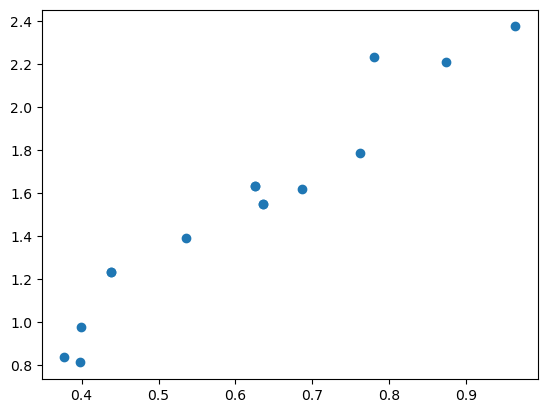

In [116]:
#Ok the growing season values and year-round values are highly collinear
#plt.scatter(sites.P90_Kd490, sites.P90_Kd490_Growing)
#plt.scatter(sites.Mean_Kd490, sites.Mean_Kd490_Growing)
plt.scatter(sites.Mean_Kd490, sites.P90_Kd490)

In [117]:
sites.to_csv('C:/Users/sarah/Documents/GitHub/ORKA_StatusReport_FollowupPaper/StatusReport_FollowupPaper_Data/MasterSites_WithKd490Metrics_20132023.csv')